# Интеллектуальный анализ данных – весна 2025

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [ ]:
import math

class_counts = [8, 2]
total = 10

entropy = 0
for count in class_counts:
    if count == 0:
        continue
    p = count / total
    entropy -= p * math.log(p)

entropy_rounded = round(entropy, 2)

print("Энтропия:", entropy_rounded)

Энтропия: 0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [ ]:
class_counts_parent = [8, 2]
class_counts_left = [8, 0]
class_counts_right = [0, 2]

total_parent = sum(class_counts_parent)
p_k1_parent = class_counts_parent[0] / total_parent
p_k2_parent = class_counts_parent[1] / total_parent
H_Rm = 1 - (p_k1_parent**2 + p_k2_parent**2)

total_left = sum(class_counts_left)
if total_left != 0:
    p_k1_left = class_counts_left[0] / total_left
    p_k2_left = class_counts_left[1] / total_left
    H_Rl = 1 - (p_k1_left**2 + p_k2_left**2)
else:
    H_Rl = 0

total_right = sum(class_counts_right)
if total_right != 0:
    p_k1_right = class_counts_right[0] / total_right
    p_k2_right = class_counts_right[1] / total_right
    H_Rr = 1 - (p_k1_right**2 + p_k2_right**2)
else:
    H_Rr = 0

N_Rm = total_parent
N_Rl = total_left
N_Rr = total_right
Q = round(H_Rm - (N_Rl / N_Rm) * H_Rl - (N_Rr / N_Rm) * H_Rr, 2)

print("Критерий информативности:", Q)

Критерий информативности: 0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [ ]:
target_values = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]
prediction = round(sum(target_values) / len(target_values), 2)

print("Предсказание модели для всех объектов в листе:", prediction)

Предсказание модели для всех объектов в листе: 40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [ ]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [ ]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    feature_vector = np.array(feature_vector).flatten()
    target_vector = np.array(target_vector).flatten()

    if len(np.unique(feature_vector)) == 1:
        return np.array([]), np.array([]), 0.0, 0.0

    if feature_type == "real":
        sort_idx = np.argsort(feature_vector)
        sorted_feature = feature_vector[sort_idx]
        sorted_target = target_vector[sort_idx]

        thresholds = (sorted_feature[1:] + sorted_feature[:-1]) / 2
        unique_thresholds = np.unique(thresholds)

        if task == "classification":
            left_cumsum = np.cumsum(sorted_target[:-1])
            left_counts = np.arange(1, len(sorted_target))

            p_left = left_cumsum / left_counts
            gini_left = 1 - (p_left**2 + (1-p_left)**2)

            right_cumsum = np.sum(sorted_target) - left_cumsum
            right_counts = len(sorted_target) - left_counts

            p_right = right_cumsum / right_counts
            gini_right = 1 - (p_right**2 + (1-p_right)**2)

            ginis = (left_counts/len(sorted_target)) * gini_left + (right_counts/len(sorted_target)) * gini_right
        else:
            left_cumsum = np.cumsum(sorted_target[:-1])
            left_sq_cumsum = np.cumsum(sorted_target[:-1]**2)
            left_counts = np.arange(1, len(sorted_target))

            left_var = left_sq_cumsum/left_counts - (left_cumsum/left_counts)**2

            right_cumsum = np.sum(sorted_target) - left_cumsum
            right_sq_cumsum = np.sum(sorted_target**2) - left_sq_cumsum
            right_counts = len(sorted_target) - left_counts

            right_var = right_sq_cumsum/right_counts - (right_cumsum/right_counts)**2

            ginis = (left_counts/len(sorted_target)) * left_var + (right_counts/len(sorted_target)) * right_var

        if len(ginis) == 0:
            return np.array([]), np.array([]), 0.0, 0.0

        best_idx = np.argmin(ginis)
        return unique_thresholds, ginis, unique_thresholds[best_idx], ginis[best_idx]

    else:
        unique_values = np.unique(feature_vector)
        if len(unique_values) == 1:
            return np.array([]), np.array([]), 0.0, 0.0

        results = []
        for value in unique_values:
            mask = feature_vector == value
            left_target = target_vector[mask]
            right_target = target_vector[~mask]

            if len(left_target) == 0 or len(right_target) == 0:
                continue

            if task == "classification":
                left_p = np.mean(left_target)
                left_gini = 1 - (left_p**2 + (1-left_p)**2)

                right_p = np.mean(right_target)
                right_gini = 1 - (right_p**2 + (1-right_p)**2)

                gini = (len(left_target)/len(target_vector)) * left_gini + (len(right_target)/len(target_vector)) * right_gini
            else:
                left_var = np.var(left_target)
                right_var = np.var(right_target)

                gini = (len(left_target)/len(target_vector)) * left_var + (len(right_target)/len(target_vector)) * right_var

            results.append((value, gini))

        if not results:
            return np.array([]), np.array([]), 0.0, 0.0

        values = np.array([r[0] for r in results])
        ginis = np.array([r[1] for r in results])

        best_idx = np.argmin(ginis)
        return values, ginis, values[best_idx], ginis[best_idx]

    pass

Эту функцию можно протестировать на датасете `California`.

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

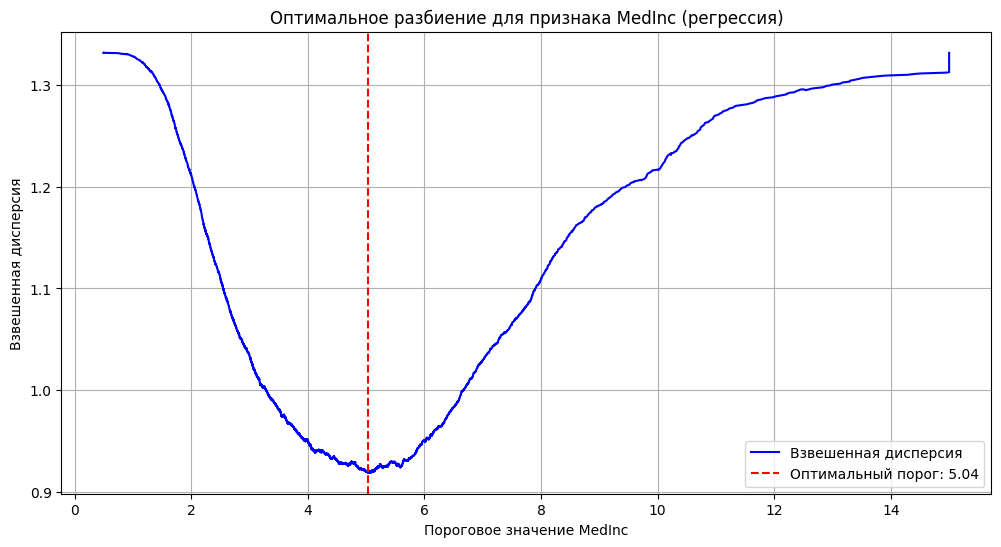

Оптимальный порог: 5.0351
Минимальная взвешенная дисперсия: 0.9188


In [ ]:
feature_name = 'MedInc'
feature = X[feature_name].values
target = y.copy()

valid_mask = ~np.isnan(feature)
feature = feature[valid_mask]
target = target[valid_mask]

sort_idx = np.argsort(feature)
sorted_feature = feature[sort_idx]
sorted_target = target[sort_idx]

thresholds = (sorted_feature[1:] + sorted_feature[:-1]) / 2

errors = []
for i in range(len(thresholds)):
    left_target = sorted_target[:i+1]
    right_target = sorted_target[i+1:]

    var_left = np.var(left_target) if len(left_target) > 0 else 0
    var_right = np.var(right_target) if len(right_target) > 0 else 0

    weight_left = len(left_target) / len(sorted_target)
    weight_right = len(right_target) / len(sorted_target)

    weighted_variance = weight_left * var_left + weight_right * var_right
    errors.append(weighted_variance)

errors = np.array(errors)

best_idx = np.argmin(errors)
best_threshold = thresholds[best_idx]
best_error = errors[best_idx]

plt.figure(figsize=(12, 6))
plt.plot(thresholds, errors, 'b-', label='Взвешенная дисперсия')
plt.axvline(x=best_threshold, color='r', linestyle='--',
            label=f'Оптимальный порог: {best_threshold:.2f}')
plt.xlabel('Пороговое значение MedInc')
plt.ylabel('Взвешенная дисперсия')
plt.title('Оптимальное разбиение для признака MedInc (регрессия)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"Минимальная взвешенная дисперсия: {best_error:.4f}")

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [ ]:
def find_best_root_split(X, y):
    best_feature = None
    best_threshold = None
    best_variance_reduction = -np.inf

    for feature_name in X.columns:
        feature = X[feature_name].values
        valid_mask = ~np.isnan(feature)
        feature = feature[valid_mask]
        target = y[valid_mask]

        if len(feature) == 0:
            continue

        sort_idx = np.argsort(feature)
        sorted_feature = feature[sort_idx]
        sorted_target = target[sort_idx]

        thresholds = (sorted_feature[1:] + sorted_feature[:-1]) / 2

        for i in range(len(thresholds)):
            left_target = sorted_target[:i+1]
            right_target = sorted_target[i+1:]

            var_left = np.var(left_target, ddof=0) if len(left_target) > 0 else 0
            var_right = np.var(right_target, ddof=0) if len(right_target) > 0 else 0

            weight_left = len(left_target) / len(sorted_target)
            weight_right = len(right_target) / len(sorted_target)

            weighted_variance = weight_left * var_left + weight_right * var_right
            variance_reduction = np.var(target) - weighted_variance

            if variance_reduction > best_variance_reduction:
                best_variance_reduction = variance_reduction
                best_threshold = thresholds[i]
                best_feature = feature_name

    return best_feature, best_threshold, best_variance_reduction

best_feature, best_threshold, variance_reduction = find_best_root_split(X, y)

print(f"Лучший признак для разбиения: {best_feature}")
print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"Снижение дисперсии: {variance_reduction:.4f}")

Лучший признак для разбиения: MedInc
Оптимальный порог: 5.0351
Снижение дисперсии: 0.4128


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [ ]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = sub_X[:, feature] < threshold
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = sub_X[:, feature] == threshold
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]

        if np.isnan(x[feature]):
            return self._predict_node(x, node["left_child"])

        if self._feature_types[feature] == "real":
            if x[feature] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

        pass

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

Загружено 258 образцов с 5 признаками
Уникальные классы: [0.    0.01  0.03  0.04  0.05  0.07  0.08  0.09  0.1   0.11  0.12  0.13
 0.14  0.15  0.16  0.18  0.19  0.2   0.21  0.22  0.23  0.24  0.25  0.26
 0.27  0.28  0.29  0.3   0.31  0.32  0.33  0.333 0.34  0.35  0.4   0.45
 0.47  0.48  0.49  0.5   0.51  0.52  0.53  0.54  0.55  0.56  0.57  0.58
 0.59  0.6   0.61  0.62  0.63  0.64  0.65  0.66  0.67  0.68  0.69  0.7
 0.71  0.74  0.75  0.76  0.77  0.78  0.79  0.8   0.81  0.82  0.83  0.84
 0.85  0.86  0.87  0.88  0.89  0.9   0.92  0.93 ]


<ipython-input-34-fd70b30dbcff>:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


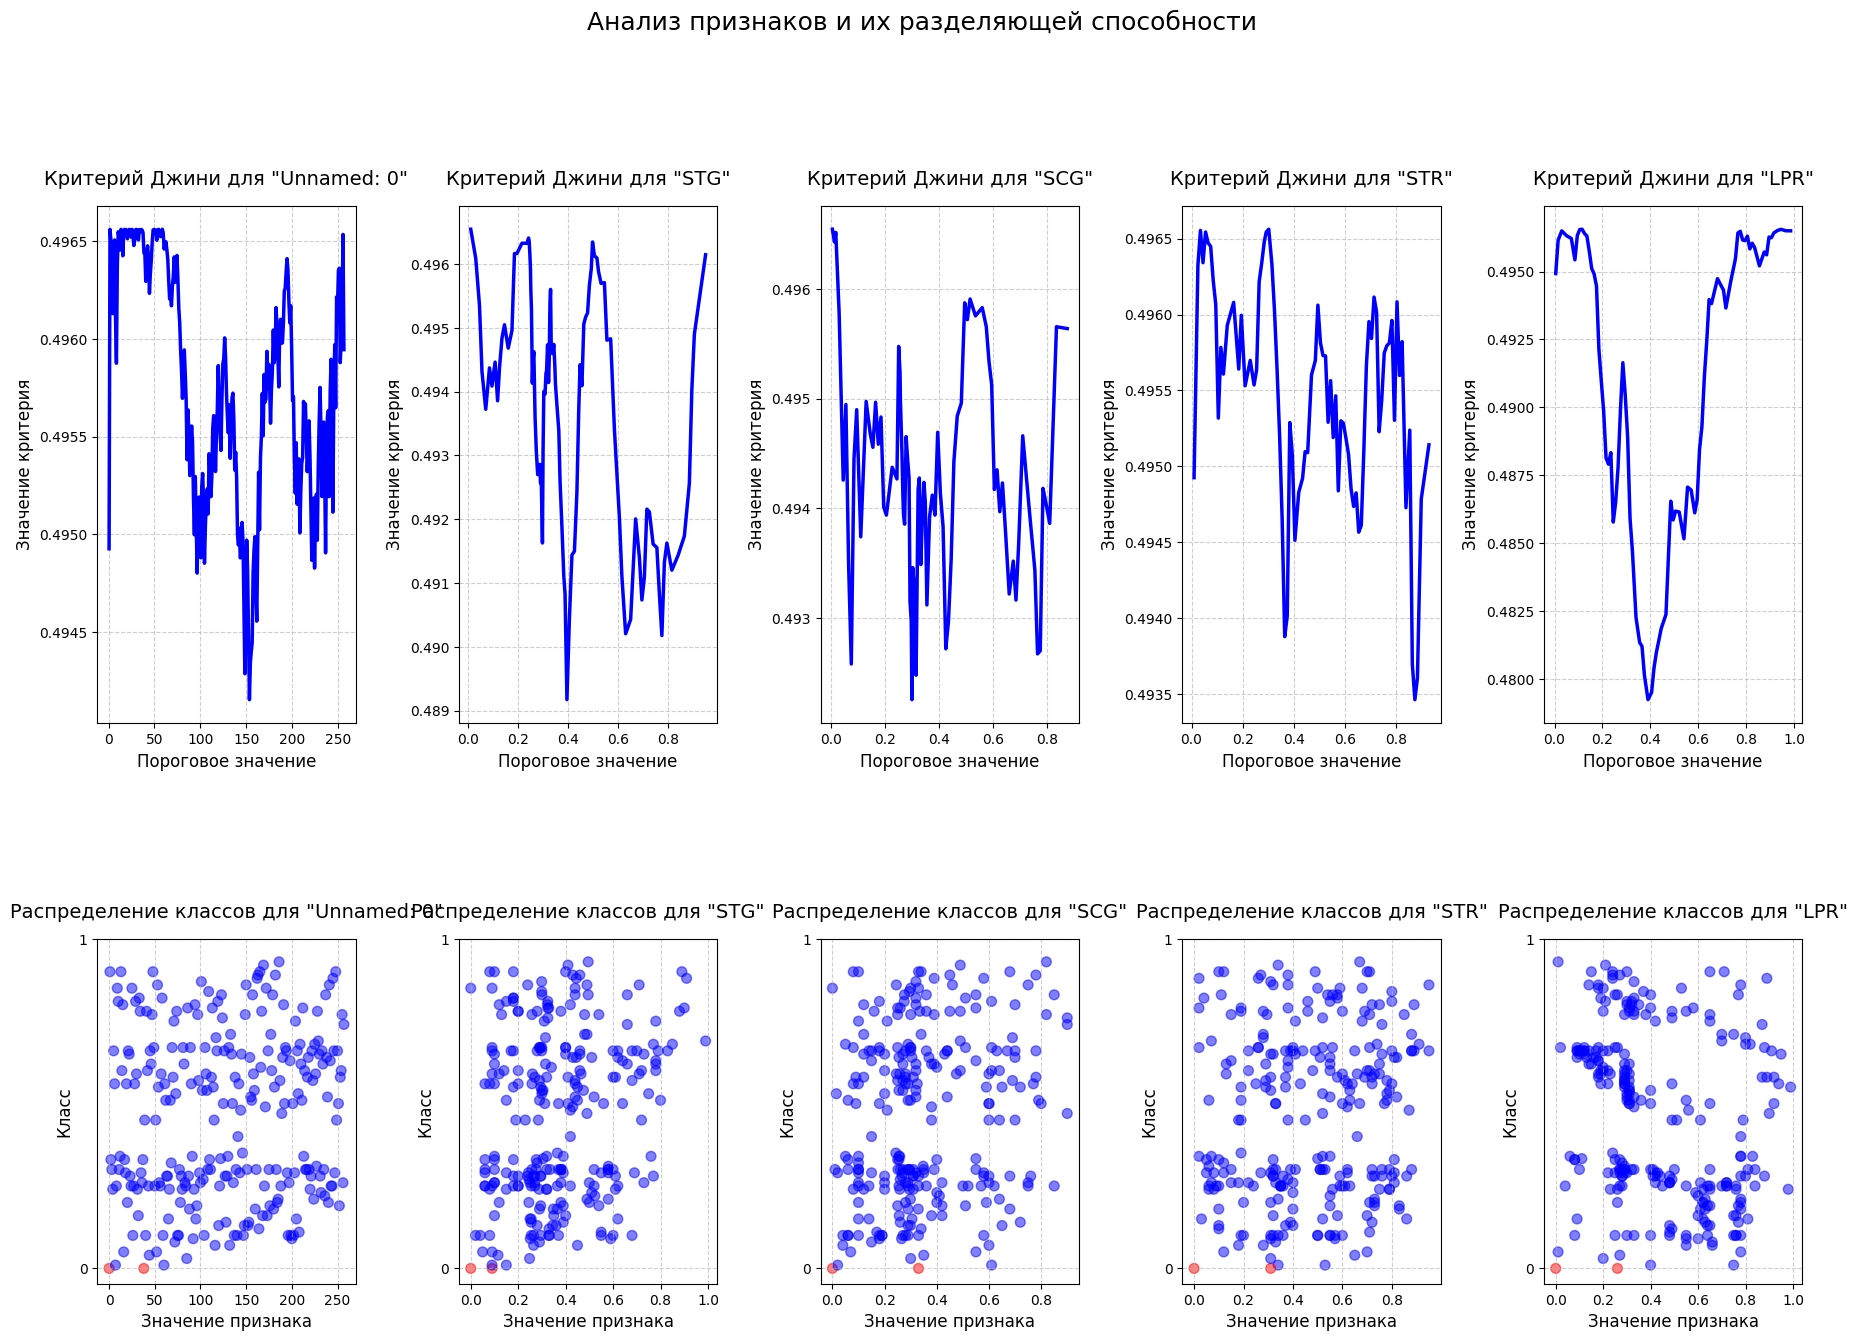

In [ ]:
from matplotlib.gridspec import GridSpec

try:
    data = pd.read_csv('students.csv')
    if len(data.columns) < 6:
        raise ValueError("Файл должен содержать как минимум 6 столбцов (5 признаков + целевая переменная)")

    X = data.iloc[:, :5].values
    y = data.iloc[:, 5].values
    feature_names = data.columns[:5].tolist()

except Exception as e:
    print(f"Ошибка загрузки данных: {e}")
    exit()

print(f"Загружено {X.shape[0]} образцов с {X.shape[1]} признаками")
print("Уникальные классы:", np.unique(y))

plt.figure(figsize=(22, 14))
gs = GridSpec(2, 5, height_ratios=[1.5, 1], hspace=0.5, wspace=0.4)

ax_gini = []
ax_scatter = []

for i in range(5):
    ax_gini.append(plt.subplot(gs[0, i]))
    ax_scatter.append(plt.subplot(gs[1, i]))

for i, (feature, name) in enumerate(zip(X.T, feature_names)):
    if np.isnan(feature).any():
        print(f"В признаке {name} обнаружены пропущенные значения, заполняем медианой")
        feature = np.where(np.isnan(feature), np.nanmedian(feature), feature)

    unique_values = np.unique(feature)
    if len(unique_values) == 1:
        print(f"Признак {name} имеет только одно уникальное значение, пропускаем")
        ax_gini[i].axis('off')
        ax_scatter[i].axis('off')
        continue

    thresholds = (unique_values[1:] + unique_values[:-1]) / 2

    gini_values = []
    for threshold in thresholds:
        left_mask = feature < threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            gini_values.append(1.0)
            continue

        p_left = np.mean(y[left_mask])
        p_right = np.mean(y[right_mask])

        gini_left = 2 * p_left * (1 - p_left)
        gini_right = 2 * p_right * (1 - p_right)

        weighted_gini = (np.sum(left_mask)*gini_left + np.sum(right_mask)*gini_right)/len(y)
        gini_values.append(weighted_gini)

    ax_gini[i].plot(thresholds, gini_values, 'b-', linewidth=2.5)
    ax_gini[i].set_title(f'Критерий Джини для "{name}"', fontsize=14, pad=15)
    ax_gini[i].set_xlabel('Пороговое значение', fontsize=12)
    ax_gini[i].set_ylabel('Значение критерия', fontsize=12)
    ax_gini[i].grid(True, linestyle='--', alpha=0.6)

    colors = ['red' if val == 0 else 'blue' for val in y]
    ax_scatter[i].scatter(feature, y, c=colors, alpha=0.5, s=50)
    ax_scatter[i].set_title(f'Распределение классов для "{name}"', fontsize=14, pad=15)
    ax_scatter[i].set_xlabel('Значение признака', fontsize=12)
    ax_scatter[i].set_ylabel('Класс', fontsize=12)
    ax_scatter[i].set_yticks([0, 1])
    ax_scatter[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Анализ признаков и их разделяющей способности', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

По критерию Джини наилучшим признаком для деления выборки является "LPR". Этот признак показывает самые низкие значения критерия Джини (минимум около 0.479), что указывает на наилучшую разделяющую способность среди всех представленных признаков

Результат  согласуется с визуальной оценкой диаграмм рассеяния. На диаграмме для признака "LPR" четко видно, что классы (синие и красные точки) группируются в различных областях пространства признаков, образуя относительно разделимые кластеры. В отличие от других признаков, где точки разных классов сильно перемешаны

Кривые для "хороших" признаков имеют глубокие провалы (значения критерия Джини резко снижаются в определенных пороговых точках), четко выраженные минимумы (есть оптимальные пороговые значения, где разделение максимально эффективно)и широкий диапазон значений

Кривые для признаков с плохой разделяющей способностью характеризуются малыми колебаниями, отсутствием глубоких провалов и высокими значениями

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

data = pd.read_csv('agaricus-lepiota.data')
data.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [ ]:
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data.drop('p', axis=1).values
y = data['p'].values

np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = len(X) // 2

X_train, y_train = X[indices[:split_idx]], y[indices[:split_idx]]
X_test, y_test = X[indices[split_idx:]], y[indices[split_idx:]]

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = {}

    def _gini(self, y):
        if len(y) == 0:
            return 0
        p = np.mean(y)
        return 2 * p * (1 - p)

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_value = None

        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])
            for value in values:
                left_mask = X[:, feature] == value
                right_mask = ~left_mask

                gini_left = self._gini(y[left_mask])
                gini_right = self._gini(y[right_mask])

                total_gini = (np.sum(left_mask) * gini_left + np.sum(right_mask) * gini_right) / len(y)

                if total_gini < best_gini:
                    best_gini = total_gini
                    best_feature = feature
                    best_value = value

        return best_feature, best_value, best_gini

    def _fit_node(self, X, y, node, depth=0):
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            node['type'] = 'leaf'
            node['class'] = Counter(y).most_common(1)[0][0]
            return

        feature, value, gini = self._best_split(X, y)

        if feature is None:
            node['type'] = 'leaf'
            node['class'] = Counter(y).most_common(1)[0][0]
            return

        node['type'] = 'node'
        node['feature'] = feature
        node['value'] = value
        node['left'], node['right'] = {}, {}

        left_mask = X[:, feature] == value
        self._fit_node(X[left_mask], y[left_mask], node['left'], depth+1)
        self._fit_node(X[~left_mask], y[~left_mask], node['right'], depth+1)

    def fit(self, X, y):
        self._fit_node(X, y, self.tree)

    def _predict_node(self, x, node):
        if node['type'] == 'leaf':
            return node['class']

        if x[node['feature']] == node['value']:
            return self._predict_node(x, node['left'])
        else:
            return self._predict_node(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_node(x, self.tree) for x in X])

tree = DecisionTree(max_depth=5)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Процент съедобных грибов в тестовой выборке: {np.mean(y_test == 0):.2f}")
print(f"Процент ядовитых грибов в тестовой выборке: {np.mean(y_test == 1):.2f}")

Accuracy: 0.9990
Процент съедобных грибов в тестовой выборке: 0.52
Процент ядовитых грибов в тестовой выборке: 0.48


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

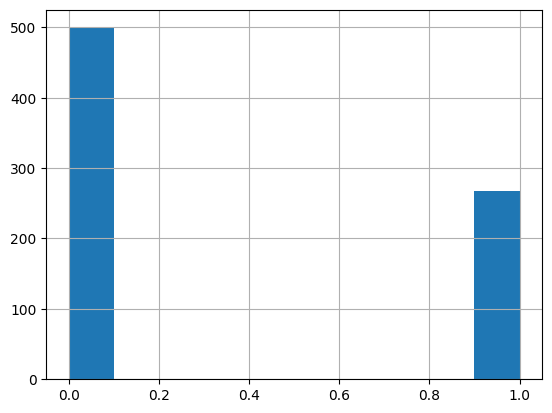

In [ ]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_train_train, X_val, y_train_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.3,  # 0.3 от 0.7 = 0.21 от исходного датасета
    random_state=42
)

print(f"Исходный размер датасета: {len(data)}")
print(f"Обучающая-обучающая выборка: {len(X_train_train)} ({len(X_train_train)/len(data):.2%})")
print(f"Валидационная выборка: {len(X_val)} ({len(X_val)/len(data):.2%})")
print(f"Тестовая выборка: {len(X_test)} ({len(X_test)/len(data):.2%})")

Исходный размер датасета: 768
Обучающая-обучающая выборка: 375 (48.83%)
Валидационная выборка: 162 (21.09%)
Тестовая выборка: 231 (30.08%)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
from sklearn.metrics import f1_score
max_depth_values = [3, 5, 7, 10, 15, 20, None]
min_samples_leaf_values = [1, 3, 5, 7, 10, 15, 20]

best_f1 = 0
best_params = {'max_depth': None, 'min_samples_leaf': None}

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        tree.fit(X_train_train, y_train_train)

        y_pred = tree.predict(X_val)

        current_f1 = f1_score(y_val, y_pred)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params['max_depth'] = max_depth
            best_params['min_samples_leaf'] = min_samples_leaf

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая F1-мера на валидационной выборке: {best_f1:.4f}")

final_tree = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
final_tree.fit(X_train, y_train)

y_pred_test = final_tree.predict(X_test)
y_proba_test = final_tree.predict_proba(X_test)[:, 1]

print("\nМетрики на тестовой выборке:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 7}
Лучшая F1-мера на валидационной выборке: 0.7143

Метрики на тестовой выборке:
Accuracy: 0.6970
Precision: 0.5556
Recall: 0.6250
F1-score: 0.5882
ROC-AUC: 0.7517


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=best_params['max_depth'],
        min_samples_leaf=best_params['min_samples_leaf'],
        random_state=42
    ),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)
y_proba_bag = bagging.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bag):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bag):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_bag):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_bag):.4f}")

Accuracy: 0.7576
Precision: 0.6463
Recall: 0.6625
F1-score: 0.6543
ROC-AUC: 0.8113


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [ ]:
from sklearn.model_selection import cross_val_score

max_depth_values = [3, 5, 7, 10, 15, 20, None]
min_samples_split_values = [2, 5, 10, 15, 20]
cv_folds = 5

best_score = 0
best_params = {'max_depth': None, 'min_samples_split': None}

for max_depth in max_depth_values:
    for min_samples_split in min_samples_split_values:
        rf = RandomForestClassifier(
            n_estimators=50,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )

        scores = cross_val_score(rf, X_train, y_train, cv=cv_folds, scoring='f1')
        mean_score = np.mean(scores)

        if mean_score > best_score:
            best_score = mean_score
            best_params['max_depth'] = max_depth
            best_params['min_samples_split'] = min_samples_split

print(f"Лучшие параметры: {best_params}")
print(f"Средняя F1-мера при кросс-валидации: {best_score:.4f}")

final_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42
)
final_rf.fit(X_train, y_train)

y_pred_rf = final_rf.predict(X_test)
y_proba_rf = final_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest (50 деревьев) - метрики на тестовой выборке:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nСравнение всех моделей на тестовой выборке:")
print("{:<25} {:<8} {:<8} {:<8} {:<8} {:<8}".format(
    "Модель", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"))
print("-"*65)
print("{:<25} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f}".format(
    "Decision Tree",
    accuracy_score(y_test, y_pred_test),
    precision_score(y_test, y_pred_test),
    recall_score(y_test, y_pred_test),
    f1_score(y_test, y_pred_test),
    roc_auc_score(y_test, y_proba_test)))
print("{:<25} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f}".format(
    "Bagging (50 деревьев)",
    accuracy_score(y_test, y_pred_bag),
    precision_score(y_test, y_pred_bag),
    recall_score(y_test, y_pred_bag),
    f1_score(y_test, y_pred_bag),
    roc_auc_score(y_test, y_proba_bag)))
print("{:<25} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f} {:<8.4f}".format(
    "Random Forest (50 деревьев)",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_proba_rf)))

Лучшие параметры: {'max_depth': 10, 'min_samples_split': 15}
Средняя F1-мера при кросс-валидации: 0.6394

Random Forest (50 деревьев) - метрики на тестовой выборке:
Accuracy: 0.7532
Precision: 0.6456
Recall: 0.6375
F1-score: 0.6415
ROC-AUC: 0.7960

Сравнение всех моделей на тестовой выборке:
Модель                    Accuracy Precision Recall   F1       ROC-AUC 
-----------------------------------------------------------------
Decision Tree             0.6970   0.5556   0.6250   0.5882   0.7517  
Bagging (50 деревьев)     0.7576   0.6463   0.6625   0.6543   0.8113  
Random Forest (50 деревьев) 0.7532   0.6456   0.6375   0.6415   0.7960  


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

n_estimators=1   | AUC-ROC=0.6755
n_estimators=5   | AUC-ROC=0.7760
n_estimators=10  | AUC-ROC=0.7888
n_estimators=20  | AUC-ROC=0.7981
n_estimators=30  | AUC-ROC=0.7919
n_estimators=40  | AUC-ROC=0.7946
n_estimators=50  | AUC-ROC=0.7964
n_estimators=75  | AUC-ROC=0.8041
n_estimators=100 | AUC-ROC=0.8082
n_estimators=150 | AUC-ROC=0.8113
n_estimators=200 | AUC-ROC=0.8084


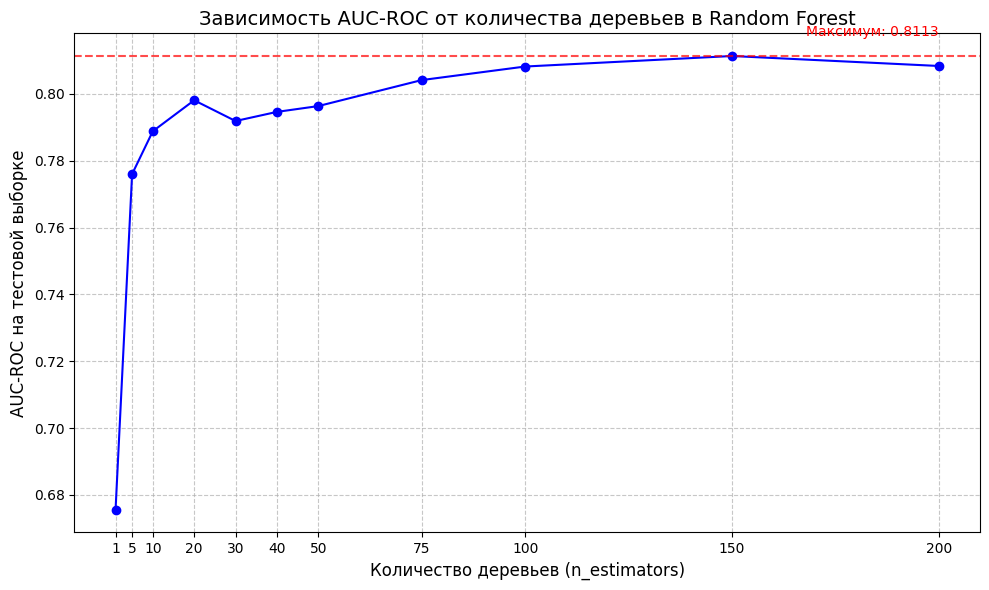

In [ ]:
n_estimators_range = [1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200]
auc_scores = []

best_max_depth = 10
best_min_samples_split = 5

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_max_depth,
        min_samples_split=best_min_samples_split,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_proba = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)
    print(f"n_estimators={n:<3} | AUC-ROC={auc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, auc_scores, marker='o', linestyle='-', color='b')
plt.title('Зависимость AUC-ROC от количества деревьев в Random Forest', fontsize=14)
plt.xlabel('Количество деревьев (n_estimators)', fontsize=12)
plt.ylabel('AUC-ROC на тестовой выборке', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(n_estimators_range)
plt.tight_layout()

max_auc = max(auc_scores)
plt.axhline(y=max_auc, color='r', linestyle='--', alpha=0.7)
plt.text(200, max_auc+0.005, f'Максимум: {max_auc:.4f}', ha='right', va='bottom', color='r')

plt.show()

ВЫВОДЫ:


Быстрый начальный рост:

При увеличении числа деревьев от 1 до ~20 наблюдается резкий рост AUC-ROC

Основное улучшение качества происходит на первых десятках деревьев

После ~50 деревьев прирост AUC-ROC становится минимальным

Диапазон 30-100 деревьев является оптимальным

Крутой начальный наклон подтверждает эффективность бэггинга


**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

<ipython-input-50-aa103768fd43>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


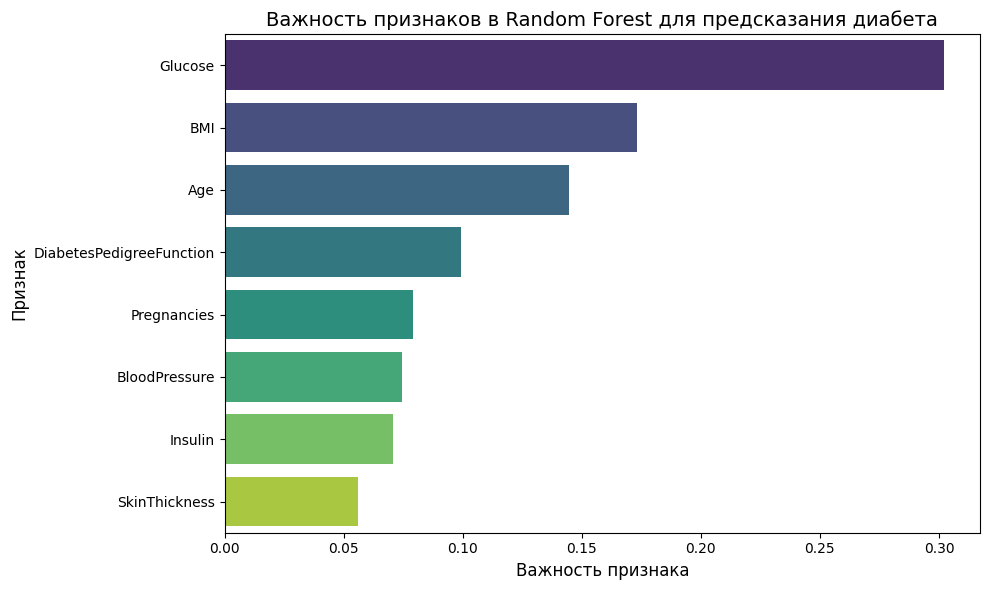


Самый важный признак: Glucose


In [ ]:
import seaborn as sns

best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
best_rf.fit(X_train, y_train)
feature_importances = best_rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Важность признаков в Random Forest для предсказания диабета', fontsize=14)
plt.xlabel('Важность признака', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

most_important_feature = importance_df.iloc[0]['Feature']
print(f"\nСамый важный признак: {most_important_feature}")